In [1]:
import torch
import vitlab
from vitlab.activations import ActivationReader
from vitlab.datasets import get_splits
from vitlab.sae import load_layer_sae

DEVICE = "cuda"
BACKBONE_CKPT = "../runs/dinov2-base_full_epochs30/best"
SAE_CKPT = "../saes/dinov2_fitz_l9_topk16_d3072"
DATASET = "fitzpatrick17k"

model  = vitlab.load_model(BACKBONE_CKPT, device=DEVICE)
reader = ActivationReader(model.backbone)
sae = load_layer_sae(SAE_CKPT, device=DEVICE)

train, _, _ = get_splits(DATASET, model_key=model.spec.key)
px = train[0]["pixel_values"].unsqueeze(0).to(DEVICE)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/7976 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1140 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2281 [00:00<?, ?it/s]

In [11]:
with torch.no_grad():
    acts    = reader.read(px, sae.spec.site)
    print(f"Activations Shape (Batch, Sequence, Dimension): {acts.shape}")
    patches = acts[:, model.spec.n_prefix_tokens:, :]
    print(f"Patches Shape (Batch, Patches, Dimension): {patches.shape}")
    codes   = sae.encode(patches.reshape(-1, patches.shape[-1]))
    print(f"Codes Shape (Batch x Sequence, SAE Dimension): {codes.shape}")

active = (codes > 0).sum(-1).float().mean()
print(f"{codes.shape[1]} concepts, {active:.1f} active per patch (should be ~top_k)")

'blocks.9.resid_post'

In [2]:
sae.spec

SAESpec(site='blocks.9.resid_post', model_key='dinov2-base', sae_class='TopKSAE', nb_concepts=3072, d_model=768, top_k=16, normalizer='zscore', dataset='', token_select='patches', num_train_tokens=2041600, final_r2=0.7823613559554717, final_dead_frac=0.1471354216337204, epochs=30, extra={'sae_type': 'TopKSAE', 'normalize': 'zscore'})

In [1]:
import torch
import vitlab
from vitlab.datasets import get_splits
from vitlab.sae import load_bank                 # -> SAEBank keyed by site
from vitlab import viz
import vitlab.attribution as A

device = "cuda"
SITE = "blocks.9.resid_post"          # must match what the SAE was trained on
BACKBONE_CKPT = "../runs/dinov2-base_full_epochs30/best"
SAE_CKPT = "../saes/dinov2_fitz_l9_topk16_d3072"
DATASET = "fitzpatrick17k"

# 1. model (backbone + task head) and the SAE bank
model = vitlab.load_model(BACKBONE_CKPT, device=device)
bank  = load_bank({SITE: SAE_CKPT}, device=device)   # {site: sae_dir}

# 2. one image, preprocessed for this backbone; keep the batch dim
train, _, _ = get_splits(DATASET, model_key=model.spec.key)
image = train[0]["pixel_values"].unsqueeze(0)      # (1, 3, 224, 224)

# 3. two-stage attribution: patching screens -> ablation verifies
task = model.task_names[0]                         # or e.g. "fitzpatrick17k"


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/7976 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1140 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2281 [00:00<?, ?it/s]

#1  blocks.9.resid_post  F2713  Δ=0.7458
#2  blocks.9.resid_post  F1015  Δ=0.3716
#3  blocks.9.resid_post  F1375  Δ=0.3568
#4  blocks.9.resid_post  F1564  Δ=0.3068
#5  blocks.9.resid_post  F2245  Δ=0.3047


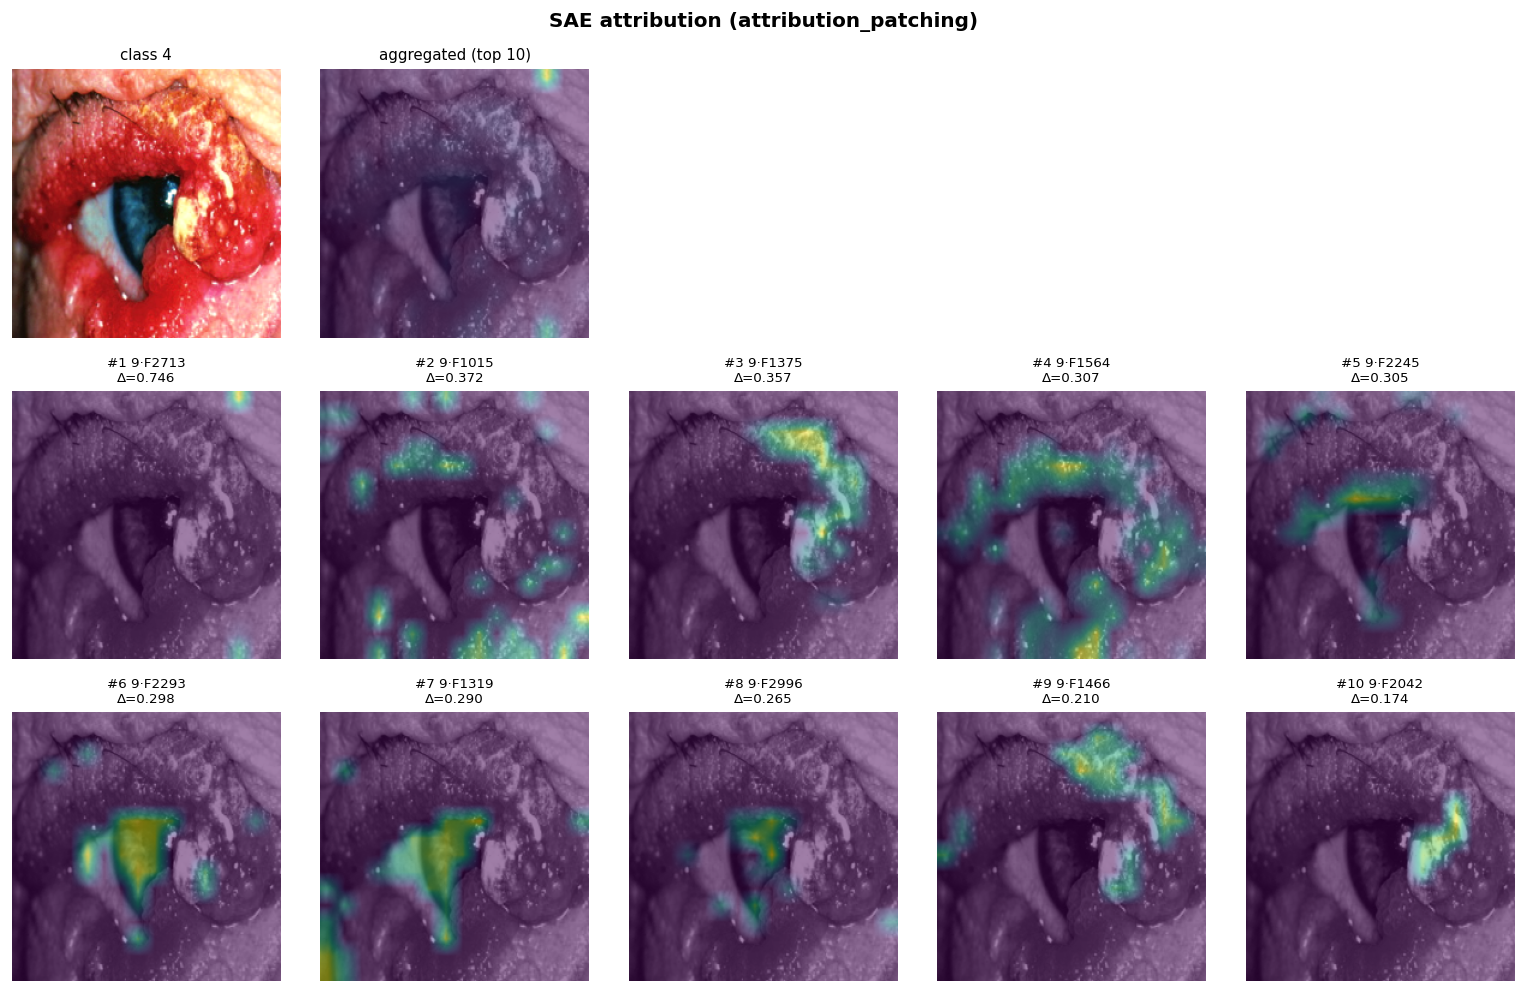

In [7]:
image = train[0]["pixel_values"].unsqueeze(0)      # (1, 3, 224, 224)
r = A.attribution_patching(model, bank, image, SITE, task=task, top_k=10, device=device)

for c in r.top(5):
    print(f"#{c['rank']}  {c['site']}  F{c['feature']}  Δ={c['score']:.4f}")

# 4. figure
viz.use_style()
fig = viz.attribution_grid(image, r, model_key=model.spec.key, save="attr.pdf", show=True)

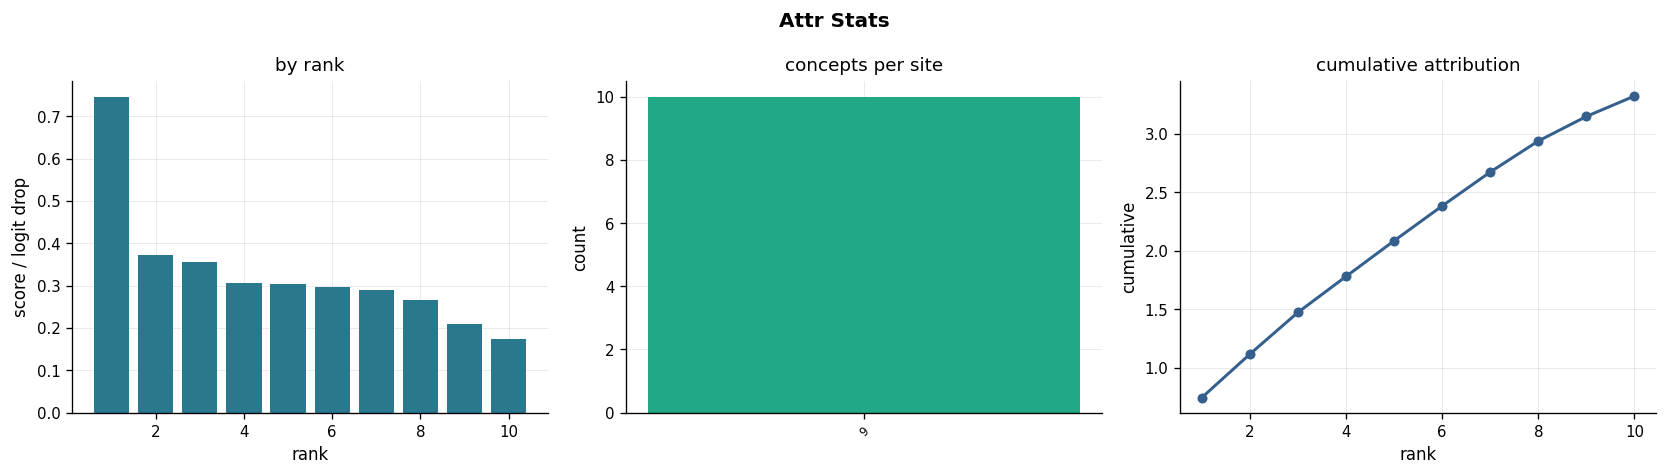

In [8]:
_ = viz.attribution_stats(r, title="Attr Stats", show=True)

layer         cls     patches   (grad mass | abl drop)
    0        0.03        0.97        +5.791      +6.201
    1        0.08        0.92        +5.426      +6.103
    2        0.11        0.89        +3.921      +6.390
    3        0.12        0.88        +4.287      +8.205
    4        0.14        0.86        +4.121      +4.137
    5        0.13        0.87        +4.579      +3.770
    6        0.21        0.79        +3.387      +6.563
    7        0.30        0.70        +4.248      +7.455
    8        0.23        0.77        +4.984      +4.356
    9        0.36        0.64        +4.633      +8.751
   10        1.00        0.00        +4.227      +4.338
   11        1.00        0.00        +2.143      +0.000


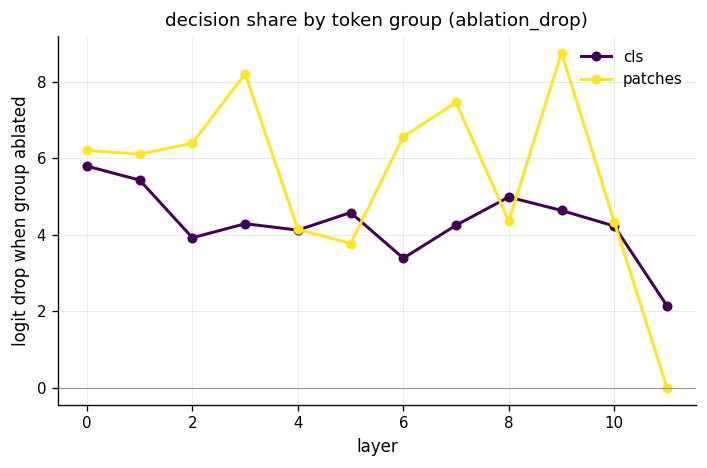

In [9]:
share = A.token_group_attribution(model, image, task=task)
print(share.table())
_ = viz.token_group_trajectory(share, measure="ablation_drop", save="tg.pdf")